- Q10 -
Returns shape: (2, 11)
[[ 0.08   -0.0463  0.1165 -0.0435  0.0818  0.0504 -0.032   0.0744 -0.0231
   0.063   0.037 ]
 [-0.025   0.0769 -0.0238  0.0732 -0.0227  0.0465  0.0222 -0.0348  0.0586
   0.0213 -0.0083]]
Annualised mean : [0.3909 0.2007]
Annualised std  : [0.202  0.1458]
Covariance matrix:
 [[ 0.0034   -0.002064]
 [-0.002064  0.001772]]
rho * sigA * sigB = -0.002064  | off-diagonal = -0.002064
- Q11 -
Equal-weight: E[Rp]=0.0933, sigma_p=0.1087
Max Sharpe = 0.5053
Best weights = [0.1986 0.1715 0.6299]
- Q12 -
sigma_p minimised at rho = -1.0000, min sigma_p = 0.0800
d(var)/d(rho) = 0.009600000000000001 > 0  -> minimum at rho = -1
- Q13 -
                AAPL      MSFT     GOOGL      AMZN
2023-01-09  0.077702 -0.027318  0.020002 -0.002284
2023-01-16 -0.001129  0.014318  0.003881  0.037857
2023-01-23  0.033442  0.005650  0.009877  0.009842
Returns shape: (51, 4)
            AAPL       MSFT      GOOGL       AMZN
count  51.000000  51.000000  51.000000  51.000000
mean    0.00560

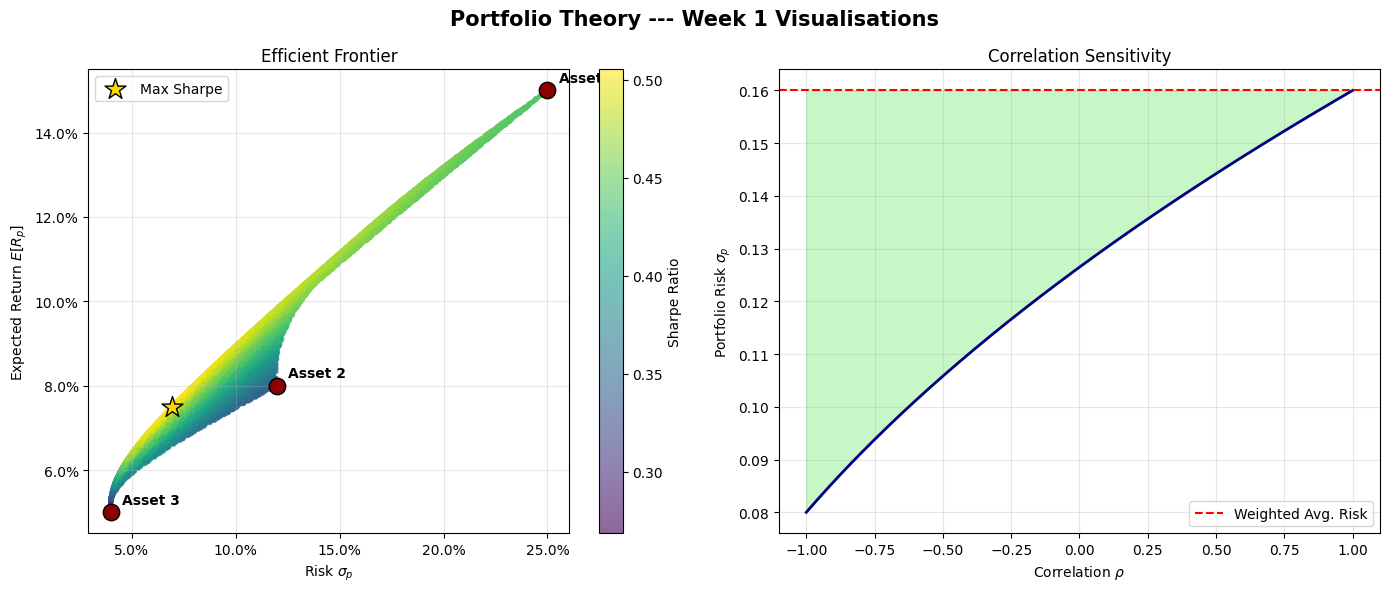

In [2]:


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import itertools


# Q10 - NumPy: returns, annualisation, covariance
print("-" , "Q10", "-" )

prices = np.array([
    [100, 108, 103, 115, 110, 119, 125, 121, 130, 127, 135, 140],  # Stock A
    [200, 195, 210, 205, 220, 215, 225, 230, 222, 235, 240, 238]   # Stock B
], dtype=float)

# (a) 11 monthly simple returns, shape (2, 11), via slicing
returns = (prices[:, 1:] - prices[:, :-1]) / prices[:, :-1]
print("Returns shape:", returns.shape)
print(np.round(returns, 4))

# (b) annualise: mean x 12, std x sqrt(12)
ann_mean = returns.mean(axis=1) * 12
ann_std = returns.std(axis=1, ddof=1) * np.sqrt(12)
print("Annualised mean :", np.round(ann_mean, 4))
print("Annualised std  :", np.round(ann_std, 4))

# (c) sample covariance matrix; check off-diagonal = rho * sigA * sigB
cov = np.cov(returns)            # uses ddof=1 by default
print("Covariance matrix:\n", np.round(cov, 6))
sigA, sigB = np.sqrt(cov[0, 0]), np.sqrt(cov[1, 1])
rho = cov[0, 1] / (sigA * sigB)
print("rho * sigA * sigB =", round(rho * sigA * sigB, 6),
      " | off-diagonal =", round(cov[0, 1], 6))   # they match by definition



# Q11 - NumPy: 3-asset portfolio maths + random search

print("-" , "Q11", "-" )

mu = np.array([0.15, 0.08, 0.05])
sig = np.array([0.25, 0.12, 0.04])
corr = np.array([[1.0, 0.4, 0.1],
                 [0.4, 1.0, 0.2],
                 [0.1, 0.2, 1.0]])
Sigma = corr * np.outer(sig, sig)          # Sigma_ij = rho_ij * sig_i * sig_j

# (a) equal-weight portfolio
w_eq = np.array([1/3, 1/3, 1/3])
Erp = w_eq @ mu
var_p = w_eq @ Sigma @ w_eq
print(f"Equal-weight: E[Rp]={Erp:.4f}, sigma_p={np.sqrt(var_p):.4f}")

# (b) 10,000 random weights via Dirichlet
np.random.seed(0)
W = np.random.dirichlet(np.ones(3), size=10000)        # (10000, 3), rows sum to 1
port_ret = W @ mu                                      # (10000,)
port_var = np.einsum('ij,jk,ik->i', W, Sigma, W)       # w' Sigma w for each row
port_std = np.sqrt(port_var)

# (c) vectorised Sharpe for all portfolios
Rf = 0.04
sharpe = (port_ret - Rf) / port_std
best = sharpe.argmax()
print(f"Max Sharpe = {sharpe[best]:.4f}")
print("Best weights =", np.round(W[best], 4))


# Q12 - NumPy: two-asset risk vs correlation

print("-" , "Q12", "-" )

mu1, s1, mu2, s2, w1 = 0.12, 0.20, 0.06, 0.10, 0.6
w2 = 1 - w1

# (a) 200 correlations, vectorised sigma_p
rhos = np.linspace(-1, 1, 200)
var_p = w1**2 * s1**2 + w2**2 * s2**2 + 2 * w1 * w2 * rhos * s1 * s2
sig_p = np.sqrt(var_p)

# (b) minimum
j = sig_p.argmin()
print(f"sigma_p minimised at rho = {rhos[j]:.4f}, min sigma_p = {sig_p[j]:.4f}")

# (c) Analytic: d(sigma_p^2)/d(rho) = 2*w1*w2*s1*s2 > 0 (constant, always positive).
#     Variance is strictly increasing in rho, so the minimum is at the left edge, rho = -1.
print("d(var)/d(rho) =", 2 * w1 * w2 * s1 * s2, "> 0  -> minimum at rho = -1")



# Q13 - Pandas: simulated prices, returns, describe, Sharpe

print("-" , "Q13", "-" )

np.random.seed(0)
dates = pd.date_range('2023-01-02', periods=52, freq='W-MON')
mu_weekly = np.array([0.003, 0.002, 0.001, 0.0015])
sig_weekly = np.array([0.04, 0.03, 0.02, 0.025])
returns_sim = np.random.normal(mu_weekly, sig_weekly, (52, 4))
prices_sim = 100 * np.cumprod(1 + returns_sim, axis=0)
df = pd.DataFrame(prices_sim, index=dates,
                  columns=['AAPL', 'MSFT', 'GOOGL', 'AMZN'])

# (a) weekly returns
rets = df.pct_change().dropna()
print(rets.head(3))
print("Returns shape:", rets.shape)            # (51, 4)

# (b) summary stats
print(rets.describe())
print("Highest mean return:", rets.mean().idxmax())
print("Highest std dev    :", rets.std().idxmax())

# (c) annualised Sharpe (Rf = 2% annual)
Rf_ann = 0.02
ann_ret = rets.mean() * 52
ann_vol = rets.std() * np.sqrt(52)
sharpe_ann = (ann_ret - Rf_ann) / ann_vol
print("Annualised Sharpe:\n", sharpe_ann.round(3))


# Q14 - Pandas: correlation, equal-weight portfolio, monthly resample
print("-" , "Q14", "-" )

# (a) correlation matrix + lowest-correlation pair
corr_mat = rets.corr()
print(corr_mat.round(3))
pairs = [(a, b, corr_mat.loc[a, b])
         for a, b in itertools.combinations(rets.columns, 2)]
lo = min(pairs, key=lambda x: x[2])
print(f"Lowest correlation pair: {lo[0]} & {lo[1]} = {lo[2]:.3f}")

# (b) equal-weight portfolio return series
weights = pd.Series(0.25, index=rets.columns)
port_rets = rets.dot(weights)

# (c) resample weekly -> monthly (compound within each month)
monthly = port_rets.resample('ME').apply(lambda x: (1 + x).prod() - 1)
print(f"Monthly mean = {monthly.mean():.5f}, std = {monthly.std():.5f}")


# Q15 - Matplotlib: efficient frontier + correlation sensitivity

print("-" , "Q15", "-" )

np.random.seed(0)
W20 = np.random.dirichlet(np.ones(3), size=20000)
ret20 = W20 @ mu
std20 = np.sqrt(np.einsum('ij,jk,ik->i', W20, Sigma, W20))
sharpe20 = (ret20 - Rf) / std20
imax = sharpe20.argmax()

fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# --- Subplot 1: efficient frontier ---
sc = ax[0].scatter(std20, ret20, c=sharpe20, cmap='viridis', s=6, alpha=0.6)
ax[0].scatter(std20[imax], ret20[imax], marker='*', s=250,
              c='gold', edgecolor='black', zorder=5, label='Max Sharpe')

labels = ['Asset 1', 'Asset 2', 'Asset 3']
for k in range(3):
    ax[0].scatter(sig[k], mu[k], s=140, c='darkred',
                  edgecolor='black', zorder=4)
    ax[0].annotate(labels[k], (sig[k], mu[k]),
                   textcoords="offset points", xytext=(8, 6), fontweight='bold')

ax[0].set_xlabel(r'Risk $\sigma_p$')
ax[0].set_ylabel(r'Expected Return $E[R_p]$')
ax[0].set_title('Efficient Frontier')
ax[0].grid(alpha=0.3)
ax[0].legend()
ax[0].xaxis.set_major_formatter(PercentFormatter(1.0))
ax[0].yaxis.set_major_formatter(PercentFormatter(1.0))
cb = fig.colorbar(sc, ax=ax[0])
cb.set_label('Sharpe Ratio')

# --- Subplot 2: correlation sensitivity ---
rhos = np.linspace(-1, 1, 200)
sig_curve = np.sqrt(w1**2 * s1**2 + w2**2 * s2**2 + 2 * w1 * w2 * rhos * s1 * s2)
wavg = w1 * s1 + w2 * s2

ax[1].plot(rhos, sig_curve, lw=2, color='navy')
ax[1].axhline(wavg, ls='--', color='red', label='Weighted Avg. Risk')
ax[1].fill_between(rhos, sig_curve, wavg, where=(sig_curve <= wavg),
                   color='lightgreen', alpha=0.5)
ax[1].set_xlabel(r'Correlation $\rho$')
ax[1].set_ylabel(r'Portfolio Risk $\sigma_p$')
ax[1].set_title('Correlation Sensitivity')
ax[1].grid(alpha=0.3)
ax[1].legend()

fig.suptitle('Portfolio Theory --- Week 1 Visualisations',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('week1_plots.png', dpi=150)
print("Saved week1_plots.png")